In [1]:
! pip install pandas numpy missingno seaborn scikit-learn


[notice] A new release of pip is available: 24.2 -> 25.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import missingno as msno
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import datasets

# first phase

In [3]:
filePath = 'combined.csv'
df = pd.read_csv(filePath)
df

,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,IWA,WHH,WHD,WHA,Time,Attendance,HHW,AHW,HO,AO
0,E0,19/08/06,Arsenal,Aston Villa,1.0,1.0,D,0.0,0.0,D,...,8.50,1.28,4.50,8.00,NaN,NaN,NaN,NaN,NaN,NaN
1,E0,19/08/06,Bolton,Tottenham,2.0,0.0,H,2.0,0.0,H,...,2.60,2.60,3.10,2.40,NaN,NaN,NaN,NaN,NaN,NaN
2,E0,19/08/06,Everton,Watford,2.0,1.0,H,1.0,0.0,H,...,4.30,1.57,3.30,5.50,NaN,NaN,NaN,NaN,NaN,NaN
3,E0,19/08/06,Newcastle,Wigan,2.0,1.0,H,1.0,0.0,H,...,4.30,1.72,3.20,4.33,NaN,NaN,NaN,NaN,NaN,NaN
4,E0,19/08/06,Portsmouth,Blackburn,3.0,0.0,H,1.0,0.0,H,...,2.60,2.20,3.10,2.87,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12926,E0,28/05/2023,Everton,Bournemouth,1.0,0.0,H,0.0,0.0,D,...,7.25,1.36,4.20,6.50,16:30,NaN,NaN,NaN,NaN,NaN
12927,E0,28/05/2023,Leeds,Tottenham,1.0,4.0,A,0.0,1.0,A,...,2.45,2.60,3.50,2.20,16:30,NaN,NaN,NaN,NaN,NaN
12928,E0,28/05/2023,Leicester,West Ham,2.0,1.0,H,1.0,0.0,H,...,3.60,1.85,3.60,3.30,16:30,NaN,NaN,NaN,NaN,NaN
12929,E0,28/05/2023,Man United,Fulham,2.0,1.0,H,1.0,1.0,D,...,5.75,1.44,4.20,5.50,16:30,NaN,NaN,NaN,NaN,NaN


In [4]:
columnsToDrop = ['Time', 'Attendance', 'HHW', 'AHW', 'HO', 'AO']
df = df.drop(columns=columnsToDrop)
df

,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,HY,AY,HR,AR,IWH,IWD,IWA,WHH,WHD,WHA
0,E0,19/08/06,Arsenal,Aston Villa,1.0,1.0,D,0.0,0.0,D,...,1.0,2.0,0.0,0.0,1.30,4.40,8.50,1.28,4.50,8.00
1,E0,19/08/06,Bolton,Tottenham,2.0,0.0,H,2.0,0.0,H,...,0.0,1.0,0.0,0.0,2.50,3.10,2.60,2.60,3.10,2.40
2,E0,19/08/06,Everton,Watford,2.0,1.0,H,1.0,0.0,H,...,2.0,2.0,0.0,0.0,1.70,3.40,4.30,1.57,3.30,5.50
3,E0,19/08/06,Newcastle,Wigan,2.0,1.0,H,1.0,0.0,H,...,1.0,2.0,0.0,0.0,1.70,3.40,4.30,1.72,3.20,4.33
4,E0,19/08/06,Portsmouth,Blackburn,3.0,0.0,H,1.0,0.0,H,...,2.0,1.0,0.0,2.0,2.50,3.10,2.60,2.20,3.10,2.87
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12926,E0,28/05/2023,Everton,Bournemouth,1.0,0.0,H,0.0,0.0,D,...,1.0,3.0,0.0,0.0,1.45,4.60,7.25,1.36,4.20,6.50
12927,E0,28/05/2023,Leeds,Tottenham,1.0,4.0,A,0.0,1.0,A,...,3.0,0.0,0.0,0.0,2.65,3.80,2.45,2.60,3.50,2.20
12928,E0,28/05/2023,Leicester,West Ham,2.0,1.0,H,1.0,0.0,H,...,1.0,1.0,0.0,0.0,1.95,3.85,3.60,1.85,3.60,3.30
12929,E0,28/05/2023,Man United,Fulham,2.0,1.0,H,1.0,1.0,D,...,1.0,2.0,0.0,0.0,1.53,4.50,5.75,1.44,4.20,5.50


In [6]:
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d', errors='coerce')
df = df.dropna(subset=['Date'])
df = df.sort_values(by='Date')
df

,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,HY,AY,HR,AR,IWH,IWD,IWA,WHH,WHD,WHA
9429,E0,1993-08-14,Arsenal,Coventry,0.0,3.0,A,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9438,E0,1993-08-14,West Ham,Wimbledon,0.0,2.0,A,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9437,E0,1993-08-14,Southampton,Everton,0.0,2.0,A,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9436,E0,1993-08-14,Sheffield United,Swindon,3.0,1.0,H,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9435,E0,1993-08-14,Oldham,Ipswich,0.0,3.0,A,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3414,NaN,2025-05-25,Man United,Aston Villa,2.0,0.0,H,0.0,0.0,D,...,2.0,2.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
3413,NaN,2025-05-25,Liverpool,Crystal Palace,1.0,1.0,D,0.0,1.0,A,...,1.0,0.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3412,NaN,2025-05-25,Ipswich,West Ham,1.0,3.0,A,0.0,1.0,A,...,1.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
3415,NaN,2025-05-25,Newcastle,Everton,0.0,1.0,A,0.0,0.0,D,...,1.0,4.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
start_date = pd.Timestamp('2000-08-18')
df = df[df['Date'] >= start_date]

In [8]:
df = df.reset_index(drop=True)
df[['Date', 'HomeTeam', 'AwayTeam']].head()

,Date,HomeTeam,AwayTeam
0,2000-08-19,Sunderland,Arsenal
1,2000-08-19,Charlton,Man City
2,2000-08-19,Chelsea,West Ham
3,2000-08-19,Coventry,Middlesbrough
4,2000-08-19,Derby,Southampton


In [9]:
df

,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,HY,AY,HR,AR,IWH,IWD,IWA,WHH,WHD,WHA
0,E0,2000-08-19,Sunderland,Arsenal,1.0,0.0,H,0.0,0.0,D,...,3.0,1.0,0.0,1.0,2.9,2.9,2.1,3.75,3.0,1.90
1,E0,2000-08-19,Charlton,Man City,4.0,0.0,H,2.0,0.0,H,...,1.0,2.0,0.0,0.0,2.2,2.9,2.7,2.10,3.2,3.10
2,E0,2000-08-19,Chelsea,West Ham,4.0,2.0,H,1.0,0.0,H,...,1.0,2.0,0.0,0.0,1.6,3.2,4.2,1.44,3.6,6.50
3,E0,2000-08-19,Coventry,Middlesbrough,1.0,3.0,A,1.0,1.0,D,...,5.0,3.0,1.0,0.0,2.2,2.9,2.7,2.30,3.2,2.62
4,E0,2000-08-19,Derby,Southampton,2.0,2.0,D,1.0,2.0,A,...,1.0,1.0,0.0,0.0,1.8,3.0,3.5,2.00,3.2,3.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9405,NaN,2025-05-25,Man United,Aston Villa,2.0,0.0,H,0.0,0.0,D,...,2.0,2.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
9406,NaN,2025-05-25,Liverpool,Crystal Palace,1.0,1.0,D,0.0,1.0,A,...,1.0,0.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
9407,NaN,2025-05-25,Ipswich,West Ham,1.0,3.0,A,0.0,1.0,A,...,1.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
9408,NaN,2025-05-25,Newcastle,Everton,0.0,1.0,A,0.0,0.0,D,...,1.0,4.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek
df

,Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,AR,IWH,IWD,IWA,WHH,WHD,WHA,Year,Month,DayOfWeek
0,E0,2000-08-19,Sunderland,Arsenal,1.0,0.0,H,0.0,0.0,D,...,1.0,2.9,2.9,2.1,3.75,3.0,1.90,2000,8,5
1,E0,2000-08-19,Charlton,Man City,4.0,0.0,H,2.0,0.0,H,...,0.0,2.2,2.9,2.7,2.10,3.2,3.10,2000,8,5
2,E0,2000-08-19,Chelsea,West Ham,4.0,2.0,H,1.0,0.0,H,...,0.0,1.6,3.2,4.2,1.44,3.6,6.50,2000,8,5
3,E0,2000-08-19,Coventry,Middlesbrough,1.0,3.0,A,1.0,1.0,D,...,0.0,2.2,2.9,2.7,2.30,3.2,2.62,2000,8,5
4,E0,2000-08-19,Derby,Southampton,2.0,2.0,D,1.0,2.0,A,...,0.0,1.8,3.0,3.5,2.00,3.2,3.20,2000,8,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9405,NaN,2025-05-25,Man United,Aston Villa,2.0,0.0,H,0.0,0.0,D,...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,2025,5,6
9406,NaN,2025-05-25,Liverpool,Crystal Palace,1.0,1.0,D,0.0,1.0,A,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2025,5,6
9407,NaN,2025-05-25,Ipswich,West Ham,1.0,3.0,A,0.0,1.0,A,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2025,5,6
9408,NaN,2025-05-25,Newcastle,Everton,0.0,1.0,A,0.0,0.0,D,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2025,5,6


In [11]:
odds_columns = ['IWH', 'IWD', 'IWA', 'WHH', 'WHD', 'WHA']
score_columns = ['FTHG', 'FTAG', 'HTHG', 'HTAG', 'HS', 'AS', 'HST', 'AST', 'HC', 'AC', 'HF', 'AF', 'HY', 'AY', 'HR', 'AR']

for col in odds_columns + score_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [12]:
df = df.drop_duplicates()

In [13]:
print(df.isna().sum())
print(df.info())

Div          380
Date           0
HomeTeam       0
AwayTeam       0
FTHG           0
FTAG           0
FTR            0
HTHG           0
HTAG           0
HTR            0
Referee        0
HS             0
AS             0
HST            0
AST            0
HC             0
AC             0
HF             0
AF             0
HY             0
AY             0
HR             0
AR             0
IWH          578
IWD          578
IWA          578
WHH          205
WHD          205
WHA          205
Year           0
Month          0
DayOfWeek      0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9410 entries, 0 to 9409
Data columns (total 32 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Div        9030 non-null   object        
 1   Date       9410 non-null   datetime64[ns]
 2   HomeTeam   9410 non-null   object        
 3   AwayTeam   9410 non-null   object        
 4   FTHG       9410 non-null   float64       
 5   FT

In [14]:
odds_columns = ['IWH', 'IWD', 'IWA', 'WHH', 'WHD', 'WHA']
df = df.dropna(subset=odds_columns)

In [15]:
df = df.drop(columns=['Div'])

In [16]:
df = df.drop_duplicates()

In [17]:
df = df.reset_index(drop=True)

In [18]:
print(df.isna().sum())
print(df.head())

Date         0
HomeTeam     0
AwayTeam     0
FTHG         0
FTAG         0
FTR          0
HTHG         0
HTAG         0
HTR          0
Referee      0
HS           0
AS           0
HST          0
AST          0
HC           0
AC           0
HF           0
AF           0
HY           0
AY           0
HR           0
AR           0
IWH          0
IWD          0
IWA          0
WHH          0
WHD          0
WHA          0
Year         0
Month        0
DayOfWeek    0
dtype: int64
        Date    HomeTeam       AwayTeam  FTHG  FTAG FTR  HTHG  HTAG HTR  \
0 2000-08-19  Sunderland        Arsenal   1.0   0.0   H   0.0   0.0   D   
1 2000-08-19    Charlton       Man City   4.0   0.0   H   2.0   0.0   H   
2 2000-08-19     Chelsea       West Ham   4.0   2.0   H   1.0   0.0   H   
3 2000-08-19    Coventry  Middlesbrough   1.0   3.0   A   1.0   1.0   D   
4 2000-08-19       Derby    Southampton   2.0   2.0   D   1.0   2.0   A   

         Referee  ...   AR  IWH  IWD  IWA   WHH  WHD   WHA  Year  Month

In [19]:
df

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,...,AR,IWH,IWD,IWA,WHH,WHD,WHA,Year,Month,DayOfWeek
0,2000-08-19,Sunderland,Arsenal,1.0,0.0,H,0.0,0.0,D,Steve Dunn,...,1.0,2.90,2.9,2.10,3.75,3.0,1.90,2000,8,5
1,2000-08-19,Charlton,Man City,4.0,0.0,H,2.0,0.0,H,Rob Harris,...,0.0,2.20,2.9,2.70,2.10,3.2,3.10,2000,8,5
2,2000-08-19,Chelsea,West Ham,4.0,2.0,H,1.0,0.0,H,Graham Barber,...,0.0,1.60,3.2,4.20,1.44,3.6,6.50,2000,8,5
3,2000-08-19,Coventry,Middlesbrough,1.0,3.0,A,1.0,1.0,D,Barry Knight,...,0.0,2.20,2.9,2.70,2.30,3.2,2.62,2000,8,5
4,2000-08-19,Derby,Southampton,2.0,2.0,D,1.0,2.0,A,Andy D'Urso,...,0.0,1.80,3.0,3.50,2.00,3.2,3.20,2000,8,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8713,2023-12-30,Man City,Sheffield United,2.0,0.0,H,1.0,0.0,H,D Coote,...,0.0,1.08,11.0,26.00,1.04,12.0,29.00,2023,12,5
8714,2023-12-31,Tottenham,Bournemouth,3.0,1.0,H,1.0,0.0,H,S Hooper,...,0.0,1.80,4.3,3.90,1.70,4.2,4.00,2023,12,6
8715,2023-12-31,Fulham,Arsenal,2.0,1.0,H,1.0,1.0,D,J Smith,...,0.0,5.50,4.3,1.57,5.50,4.2,1.53,2023,12,6
8716,2024-01-01,Liverpool,Newcastle,4.0,2.0,H,0.0,0.0,D,A Taylor,...,0.0,1.47,4.9,6.00,1.40,4.8,6.50,2024,1,0


In [20]:
df = df.copy()
df['TotalGoals'] = df['FTHG'] + df['FTAG']
df['GoalsOver2_5'] = (df['TotalGoals'] >= 2.5).astype(int)
df

,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,...,IWD,IWA,WHH,WHD,WHA,Year,Month,DayOfWeek,TotalGoals,GoalsOver2_5
0,2000-08-19,Sunderland,Arsenal,1.0,0.0,H,0.0,0.0,D,Steve Dunn,...,2.9,2.10,3.75,3.0,1.90,2000,8,5,1.0,0
1,2000-08-19,Charlton,Man City,4.0,0.0,H,2.0,0.0,H,Rob Harris,...,2.9,2.70,2.10,3.2,3.10,2000,8,5,4.0,1
2,2000-08-19,Chelsea,West Ham,4.0,2.0,H,1.0,0.0,H,Graham Barber,...,3.2,4.20,1.44,3.6,6.50,2000,8,5,6.0,1
3,2000-08-19,Coventry,Middlesbrough,1.0,3.0,A,1.0,1.0,D,Barry Knight,...,2.9,2.70,2.30,3.2,2.62,2000,8,5,4.0,1
4,2000-08-19,Derby,Southampton,2.0,2.0,D,1.0,2.0,A,Andy D'Urso,...,3.0,3.50,2.00,3.2,3.20,2000,8,5,4.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8713,2023-12-30,Man City,Sheffield United,2.0,0.0,H,1.0,0.0,H,D Coote,...,11.0,26.00,1.04,12.0,29.00,2023,12,5,2.0,0
8714,2023-12-31,Tottenham,Bournemouth,3.0,1.0,H,1.0,0.0,H,S Hooper,...,4.3,3.90,1.70,4.2,4.00,2023,12,6,4.0,1
8715,2023-12-31,Fulham,Arsenal,2.0,1.0,H,1.0,1.0,D,J Smith,...,4.3,1.57,5.50,4.2,1.53,2023,12,6,3.0,1
8716,2024-01-01,Liverpool,Newcastle,4.0,2.0,H,0.0,0.0,D,A Taylor,...,4.9,6.00,1.40,4.8,6.50,2024,1,0,6.0,1


In [21]:
df.dtypes

Date            datetime64[ns]
HomeTeam                object
AwayTeam                object
FTHG                   float64
FTAG                   float64
FTR                     object
HTHG                   float64
HTAG                   float64
HTR                     object
Referee                 object
HS                     float64
AS                     float64
HST                    float64
AST                    float64
HC                     float64
AC                     float64
HF                     float64
AF                     float64
HY                     float64
AY                     float64
HR                     float64
AR                     float64
IWH                    float64
IWD                    float64
IWA                    float64
WHH                    float64
WHD                    float64
WHA                    float64
Year                     int32
Month                    int32
DayOfWeek                int32
TotalGoals             float64
GoalsOve

In [22]:
df['HomeTeam_mean_FTHG'] = df['HomeTeam'].map(df.groupby('HomeTeam')['FTHG'].mean())
df['AwayTeam_mean_FTAG'] = df['AwayTeam'].map(df.groupby('AwayTeam')['FTAG'].mean())

df['HomeTeam_str'] = df['HomeTeam']
df['AwayTeam_str'] = df['AwayTeam']

df = pd.get_dummies(df, columns=['HomeTeam', 'AwayTeam'])

df = df.rename(columns={'HomeTeam_str': 'HomeTeam', 'AwayTeam_str': 'AwayTeam'})

In [23]:
df

,Date,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,HS,AS,...,AwayTeam_Southampton,AwayTeam_Stoke,AwayTeam_Sunderland,AwayTeam_Swansea,AwayTeam_Tottenham,AwayTeam_Watford,AwayTeam_West Brom,AwayTeam_West Ham,AwayTeam_Wigan,AwayTeam_Wolves
0,2000-08-19,1.0,0.0,H,0.0,0.0,D,Steve Dunn,8.0,14.0,...,False,False,False,False,False,False,False,False,False,False
1,2000-08-19,4.0,0.0,H,2.0,0.0,H,Rob Harris,17.0,8.0,...,False,False,False,False,False,False,False,False,False,False
2,2000-08-19,4.0,2.0,H,1.0,0.0,H,Graham Barber,17.0,12.0,...,False,False,False,False,False,False,False,True,False,False
3,2000-08-19,1.0,3.0,A,1.0,1.0,D,Barry Knight,6.0,16.0,...,False,False,False,False,False,False,False,False,False,False
4,2000-08-19,2.0,2.0,D,1.0,2.0,A,Andy D'Urso,6.0,13.0,...,True,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8713,2023-12-30,2.0,0.0,H,1.0,0.0,H,D Coote,18.0,4.0,...,False,False,False,False,False,False,False,False,False,False
8714,2023-12-31,3.0,1.0,H,1.0,0.0,H,S Hooper,12.0,24.0,...,False,False,False,False,False,False,False,False,False,False
8715,2023-12-31,2.0,1.0,H,1.0,1.0,D,J Smith,15.0,13.0,...,False,False,False,False,False,False,False,False,False,False
8716,2024-01-01,4.0,2.0,H,0.0,0.0,D,A Taylor,34.0,5.0,...,False,False,False,False,False,False,False,False,False,False


In [24]:
boolean_columns = df.select_dtypes(include=['bool']).columns
df[boolean_columns] = df[boolean_columns].astype(int)
df

,Date,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,HS,AS,...,AwayTeam_Southampton,AwayTeam_Stoke,AwayTeam_Sunderland,AwayTeam_Swansea,AwayTeam_Tottenham,AwayTeam_Watford,AwayTeam_West Brom,AwayTeam_West Ham,AwayTeam_Wigan,AwayTeam_Wolves
0,2000-08-19,1.0,0.0,H,0.0,0.0,D,Steve Dunn,8.0,14.0,...,0,0,0,0,0,0,0,0,0,0
1,2000-08-19,4.0,0.0,H,2.0,0.0,H,Rob Harris,17.0,8.0,...,0,0,0,0,0,0,0,0,0,0
2,2000-08-19,4.0,2.0,H,1.0,0.0,H,Graham Barber,17.0,12.0,...,0,0,0,0,0,0,0,1,0,0
3,2000-08-19,1.0,3.0,A,1.0,1.0,D,Barry Knight,6.0,16.0,...,0,0,0,0,0,0,0,0,0,0
4,2000-08-19,2.0,2.0,D,1.0,2.0,A,Andy D'Urso,6.0,13.0,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8713,2023-12-30,2.0,0.0,H,1.0,0.0,H,D Coote,18.0,4.0,...,0,0,0,0,0,0,0,0,0,0
8714,2023-12-31,3.0,1.0,H,1.0,0.0,H,S Hooper,12.0,24.0,...,0,0,0,0,0,0,0,0,0,0
8715,2023-12-31,2.0,1.0,H,1.0,1.0,D,J Smith,15.0,13.0,...,0,0,0,0,0,0,0,0,0,0
8716,2024-01-01,4.0,2.0,H,0.0,0.0,D,A Taylor,34.0,5.0,...,0,0,0,0,0,0,0,0,0,0


In [25]:
sns.set_style("whitegrid")

/Users/bashaar/miniforge3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


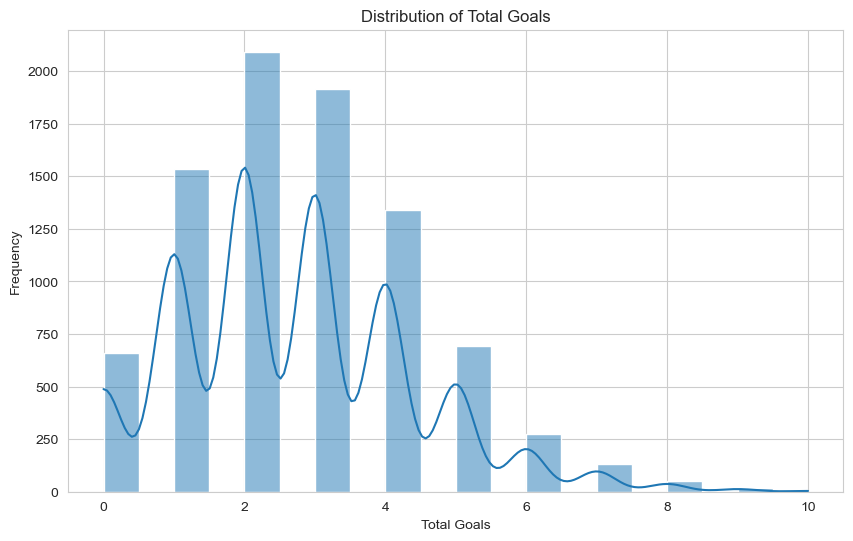

In [27]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
plt.figure(figsize=(10, 6))
sns.histplot(df['TotalGoals'], bins=20, kde=True)
plt.title('Distribution of Total Goals')
plt.xlabel('Total Goals')
plt.ylabel('Frequency')
plt.show()

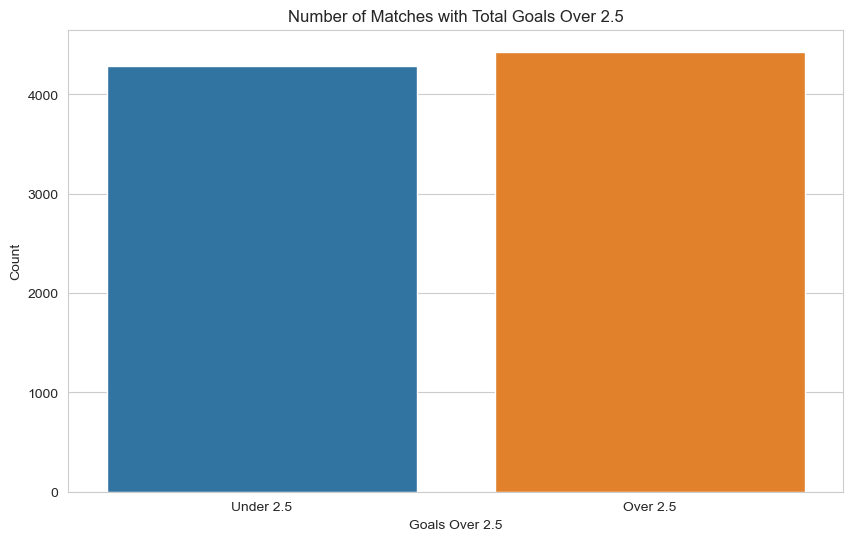

In [28]:
plt.figure(figsize=(10, 6))
sns.countplot(x='GoalsOver2_5', data=df)
plt.title('Number of Matches with Total Goals Over 2.5')
plt.xlabel('Goals Over 2.5')
plt.ylabel('Count')
plt.xticks([0, 1], ['Under 2.5', 'Over 2.5'])
plt.show()

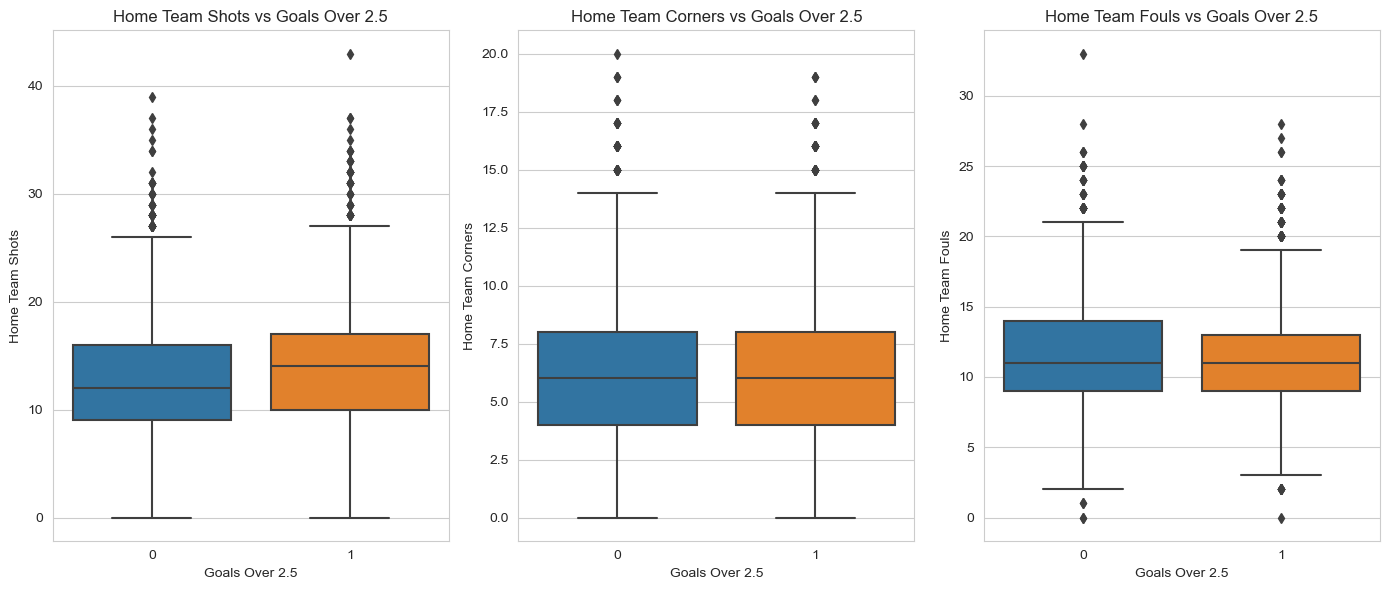

In [29]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 3, 1)
sns.boxplot(x='GoalsOver2_5', y='HS', data=df)
plt.title('Home Team Shots vs Goals Over 2.5')
plt.xlabel('Goals Over 2.5')
plt.ylabel('Home Team Shots')

plt.subplot(1, 3, 2)
sns.boxplot(x='GoalsOver2_5', y='HC', data=df)
plt.title('Home Team Corners vs Goals Over 2.5')
plt.xlabel('Goals Over 2.5')
plt.ylabel('Home Team Corners')

plt.subplot(1, 3, 3)
sns.boxplot(x='GoalsOver2_5', y='HF', data=df)
plt.title('Home Team Fouls vs Goals Over 2.5')
plt.xlabel('Goals Over 2.5')
plt.ylabel('Home Team Fouls')

plt.tight_layout()
plt.show()

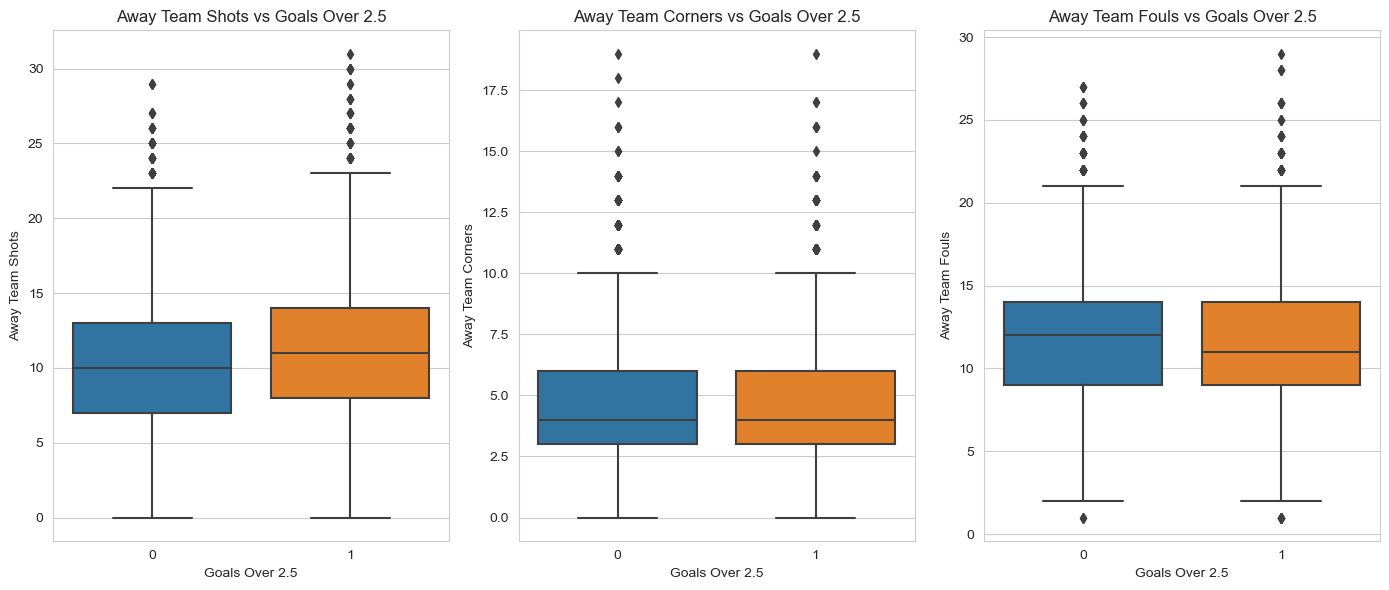

In [30]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 3, 1)
sns.boxplot(x='GoalsOver2_5', y='AS', data=df)
plt.title('Away Team Shots vs Goals Over 2.5')
plt.xlabel('Goals Over 2.5')
plt.ylabel('Away Team Shots')

plt.subplot(1, 3, 2)
sns.boxplot(x='GoalsOver2_5', y='AC', data=df)
plt.title('Away Team Corners vs Goals Over 2.5')
plt.xlabel('Goals Over 2.5')
plt.ylabel('Away Team Corners')

plt.subplot(1, 3, 3)
sns.boxplot(x='GoalsOver2_5', y='AF', data=df)
plt.title('Away Team Fouls vs Goals Over 2.5')
plt.xlabel('Goals Over 2.5')
plt.ylabel('Away Team Fouls')

plt.tight_layout()
plt.show()

In [31]:
print(df[['HomeTeam_mean_FTHG', 'AwayTeam_mean_FTAG']].head())

   HomeTeam_mean_FTHG  AwayTeam_mean_FTAG
0            1.088462            1.606407
1            1.357143            1.620525
2            2.045767            1.075916
3            0.736842            0.875000
4            0.961538            1.020270


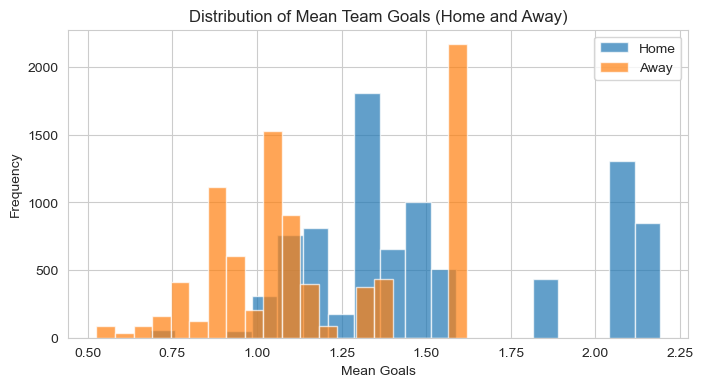

In [32]:
plt.figure(figsize=(8,4))
plt.hist(df['HomeTeam_mean_FTHG'], bins=20, alpha=0.7, label='Home')
plt.hist(df['AwayTeam_mean_FTAG'], bins=20, alpha=0.7, label='Away')
plt.xlabel('Mean Goals')
plt.ylabel('Frequency')
plt.title('Distribution of Mean Team Goals (Home and Away)')
plt.legend()
plt.show()

In [34]:
df.to_csv('cleaned_data.csv', index=False)

# second Phase / reacent form

In [35]:
print(df[['HomeTeam', 'AwayTeam', 'GoalsOver2_5']].head())

     HomeTeam       AwayTeam  GoalsOver2_5
0  Sunderland        Arsenal             0
1    Charlton       Man City             1
2     Chelsea       West Ham             1
3    Coventry  Middlesbrough             1
4       Derby    Southampton             1


In [36]:
print(df.columns.tolist())

['Date', 'FTHG', 'FTAG', 'FTR', 'HTHG', 'HTAG', 'HTR', 'Referee', 'HS', 'AS', 'HST', 'AST', 'HC', 'AC', 'HF', 'AF', 'HY', 'AY', 'HR', 'AR', 'IWH', 'IWD', 'IWA', 'WHH', 'WHD', 'WHA', 'Year', 'Month', 'DayOfWeek', 'TotalGoals', 'GoalsOver2_5', 'HomeTeam_mean_FTHG', 'AwayTeam_mean_FTAG', 'HomeTeam', 'AwayTeam', 'HomeTeam_Arsenal', 'HomeTeam_Aston Villa', 'HomeTeam_Birmingham', 'HomeTeam_Blackburn', 'HomeTeam_Blackpool', 'HomeTeam_Bolton', 'HomeTeam_Bournemouth', 'HomeTeam_Bradford', 'HomeTeam_Brentford', 'HomeTeam_Brighton', 'HomeTeam_Burnley', 'HomeTeam_Cardiff', 'HomeTeam_Charlton', 'HomeTeam_Chelsea', 'HomeTeam_Coventry', 'HomeTeam_Crystal Palace', 'HomeTeam_Derby', 'HomeTeam_Everton', 'HomeTeam_Fulham', 'HomeTeam_Huddersfield', 'HomeTeam_Hull', 'HomeTeam_Ipswich', 'HomeTeam_Leeds', 'HomeTeam_Leicester', 'HomeTeam_Liverpool', 'HomeTeam_Luton', 'HomeTeam_Man City', 'HomeTeam_Man United', 'HomeTeam_Middlesbrough', 'HomeTeam_Newcastle', 'HomeTeam_Norwich', "HomeTeam_Nott'm Forest", 'HomeT

In [37]:
with open("feature_list.txt", "w") as f:
    for col in df.columns:
        f.write(f"{col}\n")

| Feature                  | Type         | Pre-Match? | Description                                                           |
|--------------------------|--------------|------------|-----------------------------------------------------------------------|
| Date                     | Date         | Yes        | Match date                                                            |
| FTHG                     | Numeric      | No         | Full time home goals (outcome/leakage)                                |
| FTAG                     | Numeric      | No         | Full time away goals (outcome/leakage)                                |
| HTHG                     | Numeric      | No         | Half time home goals (outcome/leakage)                                |
| HTAG                     | Numeric      | No         | Half time away goals (outcome/leakage)                                |
| Referee                  | Categorical  | Yes        | Name of referee                                                       |
| HS                       | Numeric      | No         | Home team shots (usually post-match)                                  |
| AS                       | Numeric      | No         | Away team shots (post-match)                                          |
| HST                      | Numeric      | No         | Home shots on target (post-match)                                     |
| AST                      | Numeric      | No         | Away shots on target (post-match)                                     |
| HC                       | Numeric      | No         | Home corners (post-match)                                             |
| AC                       | Numeric      | No         | Away corners (post-match)                                             |
| HF                       | Numeric      | No         | Home fouls (post-match)                                               |
| AF                       | Numeric      | No         | Away fouls (post-match)                                               |
| HY                       | Numeric      | No         | Home yellow cards (post-match)                                        |
| AY                       | Numeric      | No         | Away yellow cards (post-match)                                        |
| HR                       | Numeric      | No         | Home red cards (post-match)                                           |
| AR                       | Numeric      | No         | Away red cards (post-match)                                           |
| IWH                      | Numeric      | Yes        | Bookmaker (Interwetten) odds home win (pre-match)                     |
| IWD                      | Numeric      | Yes        | Bookmaker odds draw (pre-match)                                       |
| IWA                      | Numeric      | Yes        | Bookmaker odds away win (pre-match)                                   |
| WHH                      | Numeric      | Yes        | Bookmaker (William Hill) odds home win (pre-match)                    |
| WHD                      | Numeric      | Yes        | Bookmaker odds draw (pre-match)                                       |
| WHA                      | Numeric      | Yes        | Bookmaker odds away win (pre-match)                                   |
| Year                     | Numeric      | Yes        | Year of match                                                         |
| Month                    | Numeric      | Yes        | Month of match                                                        |
| DayOfWeek                | Numeric      | Yes        | Day of week (0=Monday, etc.)                                          |
| TotalGoals               | Numeric      | No         | Total goals (outcome/leakage)                                         |
| GoalsOver2_5             | Numeric      | No         | Target: 1 if over 2.5 goals, else 0 (leakage)                         |
| HomeTeam_mean_FTHG       | Numeric      | Yes        | Average home team goals (should be pre-match form, check how computed) |
| AwayTeam_mean_FTAG       | Numeric      | Yes        | Average away team goals (should be pre-match form, check how computed) |
| HomeTeam_*               | One-hot      | Yes        | Home team identity (one-hot encoded)                                  |
| AwayTeam_*               | One-hot      | Yes        | Away team identity (one-hot encoded)                                  |
| FTR_A                    | One-hot      | No         | Full-time result: away win (outcome/leakage)                          |
| FTR_D                    | One-hot      | No         | Full-time result: draw (outcome/leakage)                              |
| FTR_H                    | One-hot      | No         | Full-time result: home win (outcome/leakage)                          |
| HTR_A                    | One-hot      | No         | Half-time result: away (outcome/leakage)                              |
| HTR_D                    | One-hot      | No         | Half-time result: draw (outcome/leakage)                              |
| HTR_H                    | One-hot      | No         | Half-time result: home (outcome/leakage)                              |

In [40]:
def add_recent_form_features(df, n_matches=5):
    base = df.copy()
    base['Date'] = pd.to_datetime(base['Date'])
    base = base.sort_values('Date')

    home_df = base[['Date', 'HomeTeam', 'FTHG', 'FTAG', 'FTR']].rename(
        columns={'HomeTeam': 'Team', 'FTHG': 'GoalsFor', 'FTAG': 'GoalsAgainst'})
    away_df = base[['Date', 'AwayTeam', 'FTAG', 'FTHG', 'FTR']].rename(
        columns={'AwayTeam': 'Team', 'FTAG': 'GoalsFor', 'FTHG': 'GoalsAgainst'})

    results = pd.concat([home_df, away_df], ignore_index=True)
    results = results.sort_values(['Team', 'Date'])

    def get_points(row):
        if row['GoalsFor'] > row['GoalsAgainst']:
            return 3
        elif row['GoalsFor'] == row['GoalsAgainst']:
            return 1
        else:
            return 0
    results['Points'] = results.apply(get_points, axis=1)

    results['RollingGF'] = results.groupby('Team')['GoalsFor'].transform(lambda x: x.shift().rolling(n_matches, min_periods=1).mean())
    results['RollingGA'] = results.groupby('Team')['GoalsAgainst'].transform(lambda x: x.shift().rolling(n_matches, min_periods=1).mean())
    results['RollingPoints'] = results.groupby('Team')['Points'].transform(lambda x: x.shift().rolling(n_matches, min_periods=1).sum())

    def get_form(row, team_col):
        team = row[team_col]
        date = row['Date']
        row_form = results[(results['Team'] == team) & (results['Date'] < date)].sort_values('Date').tail(1)
        if row_form.empty:
            return pd.Series([np.nan, np.nan, np.nan])
        return row_form[['RollingGF', 'RollingGA', 'RollingPoints']].values[0]

    base[['HomeRecentGF', 'HomeRecentGA', 'HomeRecentPts']] = base.apply(
        lambda row: get_form(row, 'HomeTeam'), axis=1, result_type='expand')
    base[['AwayRecentGF', 'AwayRecentGA', 'AwayRecentPts']] = base.apply(
        lambda row: get_form(row, 'AwayTeam'), axis=1, result_type='expand')

    return base

In [41]:
df_with_form = add_recent_form_features(df, n_matches=5)

In [42]:
df_with_form.head(90)

,Date,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,HS,AS,...,AwayTeam_West Brom,AwayTeam_West Ham,AwayTeam_Wigan,AwayTeam_Wolves,HomeRecentGF,HomeRecentGA,HomeRecentPts,AwayRecentGF,AwayRecentGA,AwayRecentPts
0,2000-08-19,1.0,0.0,H,0.0,0.0,D,Steve Dunn,8.0,14.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2000-08-19,4.0,0.0,H,2.0,0.0,H,Rob Harris,17.0,8.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2000-08-19,4.0,2.0,H,1.0,0.0,H,Graham Barber,17.0,12.0,...,0,1,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2000-08-19,1.0,3.0,A,1.0,1.0,D,Barry Knight,6.0,16.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2000-08-19,2.0,2.0,D,1.0,2.0,A,Andy D'Urso,6.0,13.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,2000-10-14,2.0,0.0,H,2.0,0.0,H,Barry Knight,13.0,10.0,...,0,0,0,0,1.2,1.4,5.0,0.2,2.0,2.0
82,2000-10-14,1.0,1.0,D,0.0,0.0,D,David Ellaray,7.0,7.0,...,0,0,0,0,1.6,2.0,5.0,1.4,1.0,8.0
87,2000-10-15,0.0,4.0,A,0.0,1.0,A,Steve Bennett,6.0,16.0,...,0,0,0,0,1.8,2.0,4.0,2.2,1.6,9.0
88,2000-10-16,1.0,3.0,A,0.0,1.0,A,Steve Dunn,8.0,15.0,...,0,0,0,0,1.4,1.8,3.0,0.8,0.6,7.0


In [47]:
cols = ['HomeRecentGF', 'HomeRecentGA', 'HomeRecentPts', 'AwayRecentGF', 'AwayRecentGA', 'AwayRecentPts']
print(df_with_form[cols].isna().sum())

HomeRecentGF     44
HomeRecentGA     44
HomeRecentPts    44
AwayRecentGF     48
AwayRecentGA     48
AwayRecentPts    48
dtype: int64


In [48]:
cols = ['HomeRecentGF', 'HomeRecentGA', 'HomeRecentPts', 'AwayRecentGF', 'AwayRecentGA', 'AwayRecentPts']
df_with_form = df_with_form.dropna(subset=cols)
print(df_with_form.shape)

(8646, 133)


In [49]:
def ocd_data_check(df):
    print("===== OCD Data Check Report (Model-Ready) =====")
    print(f"Shape: {df.shape}")
    
    # 1. Columns with missing values
    print("\n1. Columns with missing values:")
    na = df.isna().sum()
    na = na[na > 0]
    print(na if not na.empty else "None")
    
    # 2. Duplicate rows (entire row)
    print("\n2. Duplicate rows (entire row):", df.duplicated().sum())
    
    # 3. Date range and future dates
    print("\n3. Date range and future dates:")
    if 'Date' in df.columns:
        print("   Min:", df['Date'].min(), "Max:", df['Date'].max())
        print("   Future dates:", (pd.to_datetime(df['Date']) > pd.Timestamp.today()).sum())
    else:
        print("   No 'Date' column found.")
    
    # 4. Team columns presence (one-hot)
    home_teams = [c for c in df.columns if c.startswith('HomeTeam_')]
    away_teams = [c for c in df.columns if c.startswith('AwayTeam_')]
    print("\n4. Team one-hot columns:")
    print(f"   Number of HomeTeam_* columns: {len(home_teams)}")
    print(f"   Number of AwayTeam_* columns: {len(away_teams)}")
    print(f"   HomeTeam teams: {[c.replace('HomeTeam_','') for c in home_teams]}")
    print(f"   AwayTeam teams: {[c.replace('AwayTeam_','') for c in away_teams]}")
    missing_home = set([c.replace('AwayTeam_','') for c in away_teams]) - set([c.replace('HomeTeam_','') for c in home_teams])
    missing_away = set([c.replace('HomeTeam_','') for c in home_teams]) - set([c.replace('AwayTeam_','') for c in away_teams])
    if missing_home or missing_away:
        print(f"   Teams missing from HomeTeam: {missing_home}")
        print(f"   Teams missing from AwayTeam: {missing_away}")
    else:
        print("   HomeTeam and AwayTeam one-hot columns match.")

    # 5. Check that each row only has one HomeTeam and one AwayTeam flagged
    print("\n5. Unique one-hot team per row check:")
    if home_teams and away_teams:
        home_sum = df[home_teams].sum(axis=1)
        away_sum = df[away_teams].sum(axis=1)
        print("   Rows with != 1 HomeTeam one-hot:", (home_sum != 1).sum())
        print("   Rows with != 1 AwayTeam one-hot:", (away_sum != 1).sum())
    else:
        print("   One-hot columns for team not found.")
    
    # 6. Bookmaker odds sanity
    odds_cols = [c for c in df.columns if c in ['IWH','IWD','IWA','WHH','WHD','WHA']]
    print("\n6. Bookmaker odds columns stats:")
    if odds_cols:
        print(df[odds_cols].describe())
        for col in odds_cols:
            print(f"   {col} <= 0 values:", (df[col] <= 0).sum())
    else:
        print("   No bookmaker odds columns found.")
    
    # 7. Calendar features check
    for cal_col in ['Year','Month','DayOfWeek']:
        if cal_col in df.columns:
            print(f"\n7. {cal_col} column: min={df[cal_col].min()}, max={df[cal_col].max()}")
        else:
            print(f"\n7. {cal_col} column not found.")
    
    # 8. Recent form columns sanity
    recent_cols = ['HomeRecentGF', 'HomeRecentGA', 'HomeRecentPts', 'AwayRecentGF', 'AwayRecentGA', 'AwayRecentPts']
    existing_recent_cols = [c for c in recent_cols if c in df.columns]
    print("\n8. Recent form columns sanity:")
    if existing_recent_cols:
        print(df[existing_recent_cols].describe())
        for col in existing_recent_cols:
            print(f"   {col} < 0 values:", (df[col] < 0).sum())
    else:
        print("   No recent form columns found.")
    
    # 9. Mean team stats
    for mean_col in ['HomeTeam_mean_FTHG','AwayTeam_mean_FTAG']:
        if mean_col in df.columns:
            print(f"\n9. {mean_col}: min={df[mean_col].min()}, max={df[mean_col].max()}, mean={df[mean_col].mean()}")
        else:
            print(f"\n9. {mean_col} column not found.")
    
    # 10. New: HomeTeam and AwayTeam string columns
    print("\n10. HomeTeam/AwayTeam string columns sanity:")
    if 'HomeTeam' in df.columns and 'AwayTeam' in df.columns:
        print(f"   Number of unique HomeTeam: {df['HomeTeam'].nunique()}")
        print(f"   Number of unique AwayTeam: {df['AwayTeam'].nunique()}")
        print(f"   Example HomeTeams: {df['HomeTeam'].unique()[:10]}")
        print(f"   Example AwayTeams: {df['AwayTeam'].unique()[:10]}")
        # Check for missing or blank values
        print(f"   Missing HomeTeam values: {df['HomeTeam'].isna().sum() + (df['HomeTeam'] == '').sum()}")
        print(f"   Missing AwayTeam values: {df['AwayTeam'].isna().sum() + (df['AwayTeam'] == '').sum()}")
        # Check for mismatches with one-hot encoding
        home_onehot_set = set([c.replace('HomeTeam_', '') for c in home_teams])
        away_onehot_set = set([c.replace('AwayTeam_', '') for c in away_teams])
        home_str_set = set(df['HomeTeam'].unique())
        away_str_set = set(df['AwayTeam'].unique())
        print(f"   HomeTeam string col teams not in one-hot: {home_str_set - home_onehot_set}")
        print(f"   AwayTeam string col teams not in one-hot: {away_str_set - away_onehot_set}")
    else:
        print("   HomeTeam and/or AwayTeam string columns not found.")
    
    print("\n===== End of OCD Data Check (Model-Ready) =====")

In [50]:
ocd_data_check(df_with_form)

===== OCD Data Check Report (Model-Ready) =====
Shape: (8646, 133)

1. Columns with missing values:
None

2. Duplicate rows (entire row): 0

3. Date range and future dates:
   Min: 2000-08-26 00:00:00 Max: 2024-01-02 00:00:00
   Future dates: 0

4. Team one-hot columns:
   Number of HomeTeam_* columns: 47
   Number of AwayTeam_* columns: 47
   HomeTeam teams: ['mean_FTHG', 'Arsenal', 'Aston Villa', 'Birmingham', 'Blackburn', 'Blackpool', 'Bolton', 'Bournemouth', 'Bradford', 'Brentford', 'Brighton', 'Burnley', 'Cardiff', 'Charlton', 'Chelsea', 'Coventry', 'Crystal Palace', 'Derby', 'Everton', 'Fulham', 'Huddersfield', 'Hull', 'Ipswich', 'Leeds', 'Leicester', 'Liverpool', 'Luton', 'Man City', 'Man United', 'Middlesbrough', 'Newcastle', 'Norwich', "Nott'm Forest", 'Portsmouth', 'QPR', 'Reading', 'Sheffield United', 'Southampton', 'Stoke', 'Sunderland', 'Swansea', 'Tottenham', 'Watford', 'West Brom', 'West Ham', 'Wigan', 'Wolves']
   AwayTeam teams: ['mean_FTAG', 'Arsenal', 'Aston Villa', 

In [51]:
df_with_form

,Date,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,HS,AS,...,AwayTeam_West Brom,AwayTeam_West Ham,AwayTeam_Wigan,AwayTeam_Wolves,HomeRecentGF,HomeRecentGA,HomeRecentPts,AwayRecentGF,AwayRecentGA,AwayRecentPts
19,2000-08-26,1.0,2.0,A,0.0,2.0,A,Andy D'Urso,14.0,9.0,...,0,0,0,0,0.0,4.0,0.0,1.0,3.0,0.0
20,2000-08-26,5.0,3.0,H,1.0,2.0,A,Steve Lodge,18.0,7.0,...,0,0,0,0,0.0,1.0,0.0,4.0,0.0,3.0
21,2000-08-26,1.0,0.0,H,0.0,0.0,D,Graham Poll,14.0,9.0,...,0,0,0,0,1.0,3.0,0.0,1.0,0.0,3.0
22,2000-08-26,0.0,0.0,D,0.0,0.0,D,Steve Bennett,8.0,13.0,...,0,0,0,0,0.0,1.0,0.0,0.0,0.0,1.0
23,2000-08-26,2.0,2.0,D,2.0,0.0,H,Mike Riley,12.0,7.0,...,0,0,0,0,0.0,2.0,0.0,2.0,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8713,2023-12-30,2.0,0.0,H,1.0,0.0,H,D Coote,18.0,4.0,...,0,0,0,0,1.6,1.6,6.0,0.4,2.0,4.0
8714,2023-12-31,3.0,1.0,H,1.0,0.0,H,S Hooper,12.0,24.0,...,0,0,0,0,2.4,1.4,10.0,2.6,1.0,13.0
8715,2023-12-31,2.0,1.0,H,1.0,1.0,D,J Smith,15.0,13.0,...,0,0,0,0,2.6,1.8,6.0,1.8,1.2,10.0
8716,2024-01-01,4.0,2.0,H,0.0,0.0,D,A Taylor,34.0,5.0,...,0,0,0,0,1.8,1.0,11.0,1.0,1.6,6.0


In [83]:
def impute_recent_form(df, recent_form_cols):
    df = df.copy()
    for col in recent_form_cols:
        df[col + '_missing'] = df[col].isna().astype(int)
        team_col = 'HomeTeam' if col.startswith('Home') else 'AwayTeam'
        # Fill with team mean
        df[col] = df.groupby(team_col)[col].transform(lambda x: x.fillna(x.mean()))
        # If still missing, fill with global mean
        df[col] = df[col].fillna(df[col].mean())
    return df

recent_form_cols = [
    'HomeRecentGF', 'HomeRecentGA', 'HomeRecentPts',
    'AwayRecentGF', 'AwayRecentGA', 'AwayRecentPts'
]

In [52]:
# Example code:
bad_home_col = 'HomeTeam_mean_FTHG'
bad_away_col = 'AwayTeam_mean_FTAG'
for col in [bad_home_col, bad_away_col]:
    if col in df_with_form.columns:
        df_with_form.drop(columns=col, inplace=True)

In [53]:
ocd_data_check(df_with_form)

===== OCD Data Check Report (Model-Ready) =====
Shape: (8646, 131)

1. Columns with missing values:
None

2. Duplicate rows (entire row): 0

3. Date range and future dates:
   Min: 2000-08-26 00:00:00 Max: 2024-01-02 00:00:00
   Future dates: 0

4. Team one-hot columns:
   Number of HomeTeam_* columns: 46
   Number of AwayTeam_* columns: 46
   HomeTeam teams: ['Arsenal', 'Aston Villa', 'Birmingham', 'Blackburn', 'Blackpool', 'Bolton', 'Bournemouth', 'Bradford', 'Brentford', 'Brighton', 'Burnley', 'Cardiff', 'Charlton', 'Chelsea', 'Coventry', 'Crystal Palace', 'Derby', 'Everton', 'Fulham', 'Huddersfield', 'Hull', 'Ipswich', 'Leeds', 'Leicester', 'Liverpool', 'Luton', 'Man City', 'Man United', 'Middlesbrough', 'Newcastle', 'Norwich', "Nott'm Forest", 'Portsmouth', 'QPR', 'Reading', 'Sheffield United', 'Southampton', 'Stoke', 'Sunderland', 'Swansea', 'Tottenham', 'Watford', 'West Brom', 'West Ham', 'Wigan', 'Wolves']
   AwayTeam teams: ['Arsenal', 'Aston Villa', 'Birmingham', 'Blackburn',

In [54]:
df_with_form.to_csv('recentForm_data.csv', index=False)